<a href="https://colab.research.google.com/github/shreyasgowdac-319/ML-LAB/blob/main/internals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set a random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
num_samples = 1000

data = {
    'area_sqft': np.random.normal(1500, 300, num_samples).astype(int), # Area in square feet
    'num_bedrooms': np.random.randint(1, 6, num_samples), # Number of bedrooms
    'age_years': np.random.randint(1, 50, num_samples), # Age of the property
    'location_rating': np.random.randint(1, 11, num_samples), # Location rating (1-10)
    'distance_city_center_km': np.random.normal(10, 5, num_samples).astype(int), # Distance from city center in km
}

df = pd.DataFrame(data)

# Ensure non-negative values for area and distance
df['area_sqft'] = df['area_sqft'].apply(lambda x: max(100, x))
df['distance_city_center_km'] = df['distance_city_center_km'].apply(lambda x: max(0, x))

# Generate house prices based on a linear relationship with some noise
# house_price = (coeff1 * area) + (coeff2 * bedrooms) - (coeff3 * age) + (coeff4 * location_rating) - (coeff5 * distance) + intercept + noise

# Define coefficients
coeff_area = 150
coeff_bedrooms = 20000
coeff_age = -1500
coeff_location = 10000
coeff_distance = -5000
intercept = 150000
noise = np.random.normal(0, 50000, num_samples) # Add some random noise

df['house_price'] = (
    coeff_area * df['area_sqft'] +
    coeff_bedrooms * df['num_bedrooms'] +
    coeff_age * df['age_years'] +
    coeff_location * df['location_rating'] +
    coeff_distance * df['distance_city_center_km'] +
    intercept + noise
)

# Ensure prices are not negative
df['house_price'] = df['house_price'].apply(lambda x: max(50000, x)).astype(int)

print("Synthetic dataset generated successfully:")
display(df.head())
print("\nDataset Info:")
df.info()

Synthetic dataset generated successfully:


,area_sqft,num_bedrooms,age_years,location_rating,distance_city_center_km,house_price
0,1649,4,43,8,14,424536
1,1458,1,19,4,17,409354
2,1694,3,5,2,9,433198
3,1956,5,11,6,3,636516
4,1429,3,12,9,6,444749



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   area_sqft                1000 non-null   int64
 1   num_bedrooms             1000 non-null   int64
 2   age_years                1000 non-null   int64
 3   location_rating          1000 non-null   int64
 4   distance_city_center_km  1000 non-null   int64
 5   house_price              1000 non-null   int64
dtypes: int64(6)
memory usage: 47.0 KB


In [2]:
# Define features (X) and target (y)
X = df.drop('house_price', axis=1)
y = df['house_price']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (800, 5)
Testing set shape: (200, 5)


In [3]:
# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


Mean Squared Error (MSE): 2773675934.36
Root Mean Squared Error (RMSE): 52665.70
R-squared (R2): 0.61


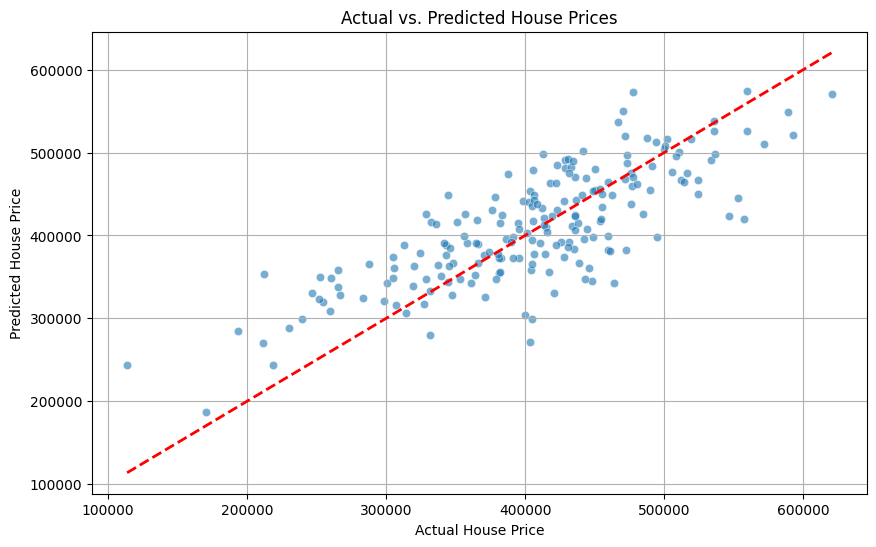

In [4]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Visualize actual vs. predicted prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs. Predicted House Prices")
plt.grid(True)
plt.show()

In [6]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) # Using 100 trees, can be tuned

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


Random Forest Mean Squared Error (MSE): 3058104662.31
Random Forest Root Mean Squared Error (RMSE): 55300.13
Random Forest R-squared (R2): 0.57


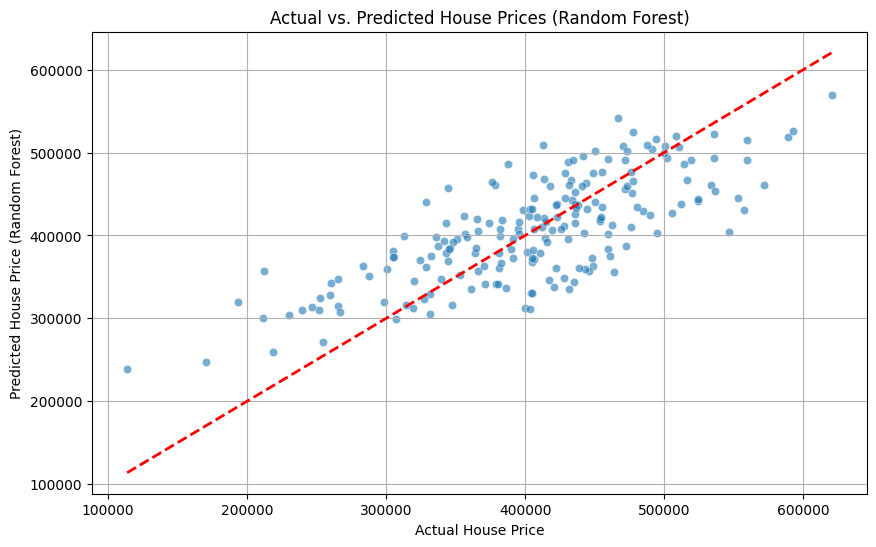

In [7]:
# Make predictions on the test set using Random Forest
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest model
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"Random Forest R-squared (R2): {r2_rf:.2f}")

# Visualize actual vs. predicted prices for Random Forest
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price (Random Forest)")
plt.title("Actual vs. Predicted House Prices (Random Forest)")
plt.grid(True)
plt.show()

In [9]:
print("\n--- Model Performance Comparison ---")
print(f"Linear Regression R-squared: {r2:.4f}")
print(f"Linear Regression RMSE: {rmse:.2f}")
print(f"Random Forest R-squared: {r2_rf:.4f}")
print(f"Random Forest RMSE: {rmse_rf:.2f}")

if r2_rf > r2:
    print("\nConclusion: The Random Forest model performs better with a higher R-squared.")
else:
    print("\nConclusion: The Linear Regression model performs better or similarly.")


--- Model Performance Comparison ---
Linear Regression R-squared: 0.6107
Linear Regression RMSE: 52665.70
Random Forest R-squared: 0.5708
Random Forest RMSE: 55300.13

Conclusion: The Linear Regression model performs better or similarly.
